# ASL Classification using MobileNetV3Small (Fine Tuning Pre-Training Layers)

Since, using just the convolution block of the MobileNetV3 model with pre-trained weights (in with_custom_layers.ipynb) yielded only **93.68%** accuracy, use the hybrid version of transer learning. 

This hybrid approach of transfer learning involves using pre-trained weights for the first several layers of the network (that have learned more general features from ImageNet) and then allow the model to tune the weights for the subsequent convolutional blocks (plus the fully connected layers). This approach is called fine-tuning because it makes small adjustments to the more abstract representations of the model being reused to make them more relevant for the problem at hand.

The transfer learning and fine-tuning process is summarized below:
- Instantiate the MobileNetV3Small convolutional base with pre-trained weights from ImageNet
- Configure the convolutional base as "trainable"
- Freeze all the layers in the convolutional base (EXCEPT the last four)
- Add a dense classifier layer for the ASL dataset
- Train the model (the last four layers of the convolutional base plus the dense classifier)

In [1]:
import numpy as np
from dataclasses import dataclass

import tensorflow as tf
import keras
from keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### Dataset and Training Config

In [2]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 224
    IMG_WIDTH: int = 224
    CHANNELS: int = 3
    NUM_CLASSES: int = 29
    BATCH_SIZE: int = 32
    DATA_ROOT: str = "./../dataset"


@dataclass(frozen=True)
class TrainingConfig:
    LEARNING_RATE: int = 0.0001
    EPOCHS: int = 50
    CHECKPOINT_FILEPATH = "./classification_asl_mobilenetv3small_fine_tuning.keras"

### MobileNetV3Small Model

The general approach to **fine-tuning** a convolutional base is to first load the pre-trained weights for the model and then selectively allow the last few convolutional layers in the base to be trainable. The process of selectively specifying which layers are trainable and which ones are not is often referred to as freezing or un-freezing layers via the model's **trainable** attribute. 

We use the term "fine-tuning" in this context because we expect the last few layers of the convolutional base (pre-trained on ImageNet) to contain feature representations that are "pretty good", but require further refinement to be more relevant for the ASL dataset.

### How to freeze only a few layers?
There are two ways to specify which layers in the model are trainable (tunable).

- We can start by making the entire convolutional base trainable by setting the trainable flag to **True**. Then loop over the initial layers and make them untrainable by setting the same (trainable) flag for each layer to **False**.

- We can freeze the entire convolutional base by setting the trainable flag to **False**, and then loop over the last few layers and set the trainable flag to **True**.

In [3]:
inputShape = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH, DatasetConfig.CHANNELS)
convBase = keras.applications.MobileNetV3Small(
    include_top=False,
    weights="imagenet",
    input_shape=inputShape,
)

convBase.trainable = False

In [4]:
print(convBase.summary())

Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

None


### Freeze all but the last four layers for Fine-Tuning

In [26]:
fineTuningLayersCount = 11
numLayers = len(convBase.layers)

for layer in convBase.layers[-fineTuningLayersCount:]:
    layer.trainable = True
    print(f"UNFREEZED layer {layer}")

print(
    f"\nConfigured to fine tune the last {fineTuningLayersCount} convolutional layers\n"
)

print(convBase.summary())

UNFREEZED layer <Conv2D name=expanded_conv_10_squeeze_excite_conv, built=True>
UNFREEZED layer <ReLU name=expanded_conv_10_squeeze_excite_relu, built=True>
UNFREEZED layer <Conv2D name=expanded_conv_10_squeeze_excite_conv_1, built=True>
UNFREEZED layer <ReLU name=re_lu_13, built=True>
UNFREEZED layer <Multiply name=expanded_conv_10_squeeze_excite_mul, built=True>
UNFREEZED layer <Conv2D name=expanded_conv_10_project, built=True>
UNFREEZED layer <BatchNormalization name=expanded_conv_10_project_bn, built=True>
UNFREEZED layer <Add name=expanded_conv_10_add, built=True>
UNFREEZED layer <Conv2D name=conv_1, built=True>
UNFREEZED layer <BatchNormalization name=conv_1_bn, built=True>
UNFREEZED layer <Activation name=activation_17, built=True>

Configured to fine tune the last 11 convolutional layers



Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

None


### Add Classification Layer

In [27]:
inputs = keras.Input(shape=inputShape)

x = keras.applications.mobilenet_v3.preprocess_input(inputs)
x = convBase(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(units=256, activation="relu")(x)
outputs = keras.layers.Dense(units=DatasetConfig.NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     7,225,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,172,173 (31.17 MB)

 Trainable params: 7,511,597 (28.65 MB)

 Non-trainable params: 660,576 (2.52 MB)

None


### Prepare the datasets

In [7]:
trainDataset, validDataset = image_dataset_from_directory(
    directory=DatasetConfig.DATA_ROOT,
    label_mode="categorical",
    batch_size=DatasetConfig.BATCH_SIZE,
    image_size=inputShape[:2],
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="both",
)

Found 4350 files belonging to 29 classes.
Using 3480 files for training.
Using 870 files for validation.


### Display Sample Images

In [8]:
classNames = trainDataset.class_names

2025-12-11 16:19:54.728515: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


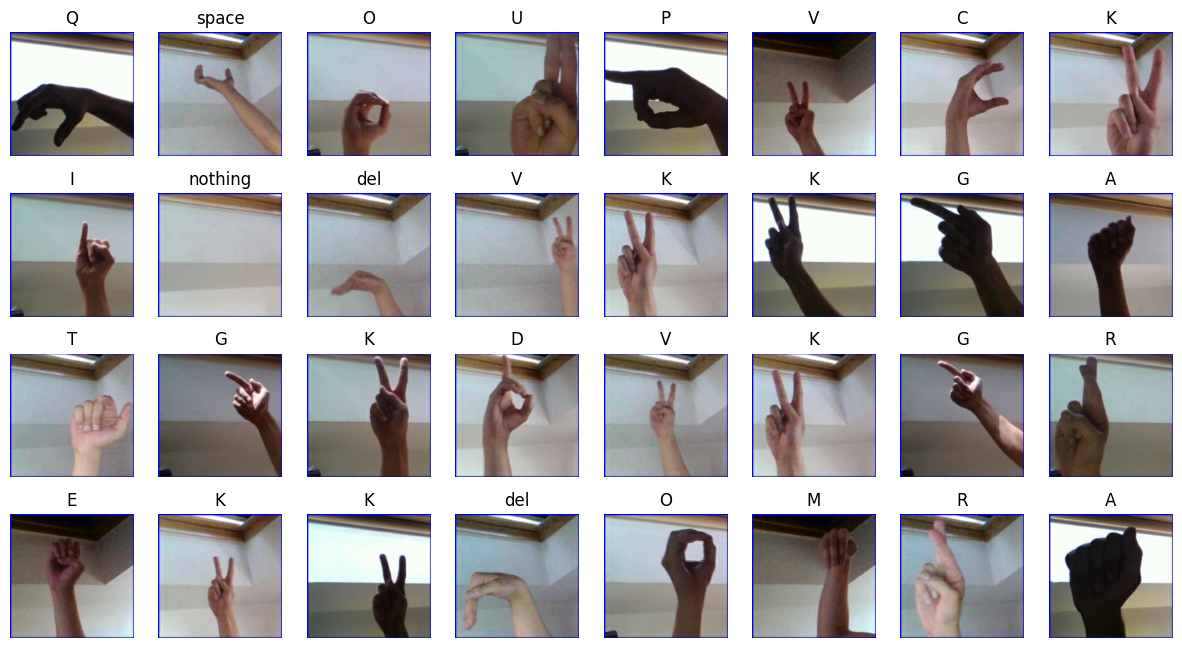

In [9]:
numRows = 4
numCols = 8

plt.figure(figsize=(15, 8))

for imagesBatch, labelsBatch in trainDataset.take(1):
    for i in range(numRows * numCols):
        ax = plt.subplot(numRows, numCols, i + 1)
        plt.imshow(imagesBatch[i].numpy().astype("uint8"))

        truthIndex = np.nonzero(labelsBatch[i].numpy())
        plt.title(classNames[truthIndex[0][0]])

        plt.axis("off")

plt.show()
plt.close()

### Compile and Train the model

In [28]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

modelCheckpointsCallback = keras.callbacks.ModelCheckpoint(
    filepath=TrainingConfig.CHECKPOINT_FILEPATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
)

In [24]:
print(f"Model accuracy: {model.evaluate(validDataset)[1]*100:.3f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.0322 - loss: 6.1471
Model accuracy: 3.218


In [29]:
trainingResults = model.fit(
    trainDataset,
    epochs=TrainingConfig.EPOCHS,
    callbacks=modelCheckpointsCallback,
    validation_data=validDataset,
)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.6218 - loss: 1.5395 - val_accuracy: 0.8540 - val_loss: 0.5212
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.9782 - loss: 0.0864 - val_accuracy: 0.9011 - val_loss: 0.3449
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - accuracy: 0.9974 - loss: 0.0120 - val_accuracy: 0.9092 - val_loss: 0.3027
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9172 - val_loss: 0.2895
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9195 - val_loss: 0.2816
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9195 - val_loss: 0.2782
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9218 - val_loss: 0.2757
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 1.0000 - loss: 8

### Plot the metrics

In [18]:
def plotMetrics(metrics, metricsNames, colours, yLabel, yLim):
    plt.figure(figsize=(15, 4))

    for i, metric in enumerate(metrics):
        plt.plot(metric, color=colours[i], label=metricsNames[i])

    plt.xlabel("Epochs")
    plt.xlim(0, TrainingConfig.EPOCHS - 1)
    plt.ylabel(yLabel)
    plt.ylim(yLim)
    plt.title(yLabel)
    plt.grid(True)

    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    plt.show(block=False)
    plt.close()

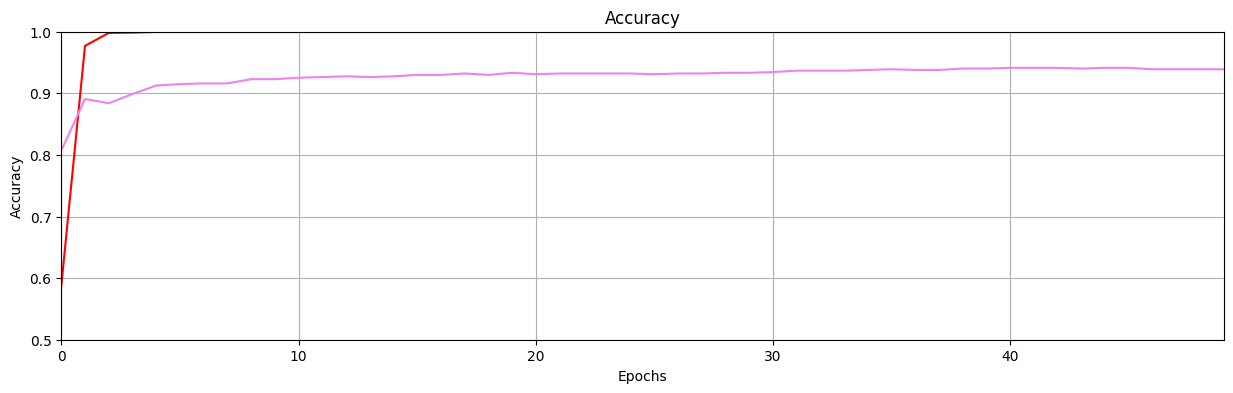

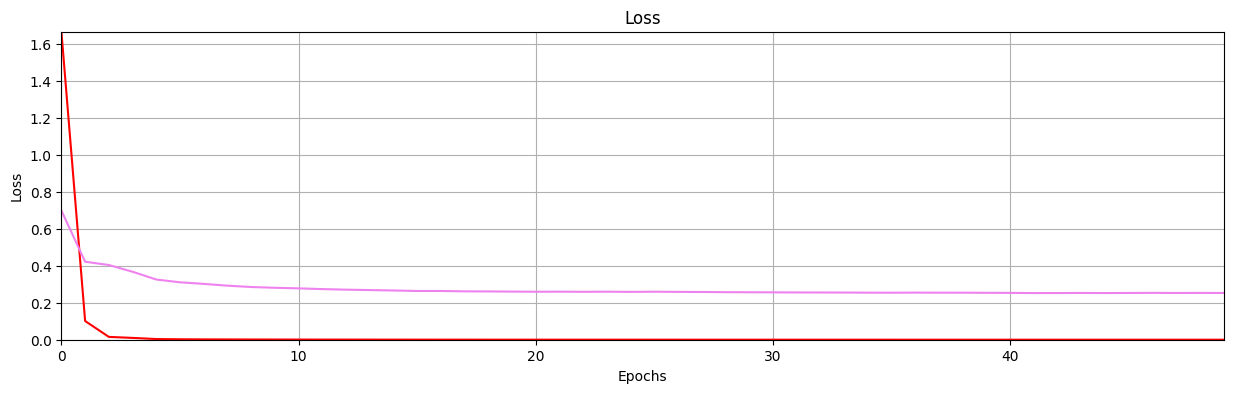

In [19]:
loss = trainingResults.history["loss"]
accuracy = trainingResults.history["accuracy"]
val_loss = trainingResults.history["val_loss"]
val_accuracy = trainingResults.history["val_accuracy"]

plotMetrics(
    metrics=[accuracy, val_accuracy],
    metricsNames=["Training Accuracy", "Validation Accuracy"],
    colours=["red", "violet"],
    yLabel="Accuracy",
    yLim=(0.5, 1.0),
)
plotMetrics(
    metrics=[loss, val_loss],
    metricsNames=["Training Loss", "Validation Loss"],
    colours=["red", "violet"],
    yLabel="Loss",
    yLim=(0.0, max(max(loss), max(val_loss))),
)

### Model Evaluation

In [15]:
savedModel = keras.models.load_model(TrainingConfig.CHECKPOINT_FILEPATH)
print(f"Saved model accuracy: {savedModel.evaluate(validDataset)[1]*100:0.3f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9414 - loss: 0.2535
Saved model accuracy: 94.138


In [16]:
def displayWrongPredictions(model, dataset):
    numRows = 4
    numCols = 8
    wrongPredictionsCount = 0

    plt.figure(figsize=(20, 15))
    for imagesBatch, labelsBatch in dataset:
        predictions = model.predict(imagesBatch)
        for idx, label in enumerate(labelsBatch):
            truthIndex = np.nonzero(label.numpy())
            predictionIndex = tf.argmax(predictions[idx]).numpy()

            if truthIndex == predictionIndex:
                continue

            wrongPredictionsCount += 1

            if wrongPredictionsCount > numRows * numCols:
                break

            ax = plt.subplot(numRows, numCols, wrongPredictionsCount)
            title = (
                str(classNames[predictionIndex])
                + " : "
                + str(classNames[truthIndex[0][0]])
            )
            titleObj = plt.title(title)

            plt.setp(titleObj, color="red")
            plt.axis("off")
            plt.imshow(imagesBatch[idx].numpy().astype("uint8"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101

2025-12-11 16:30:23.526883: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


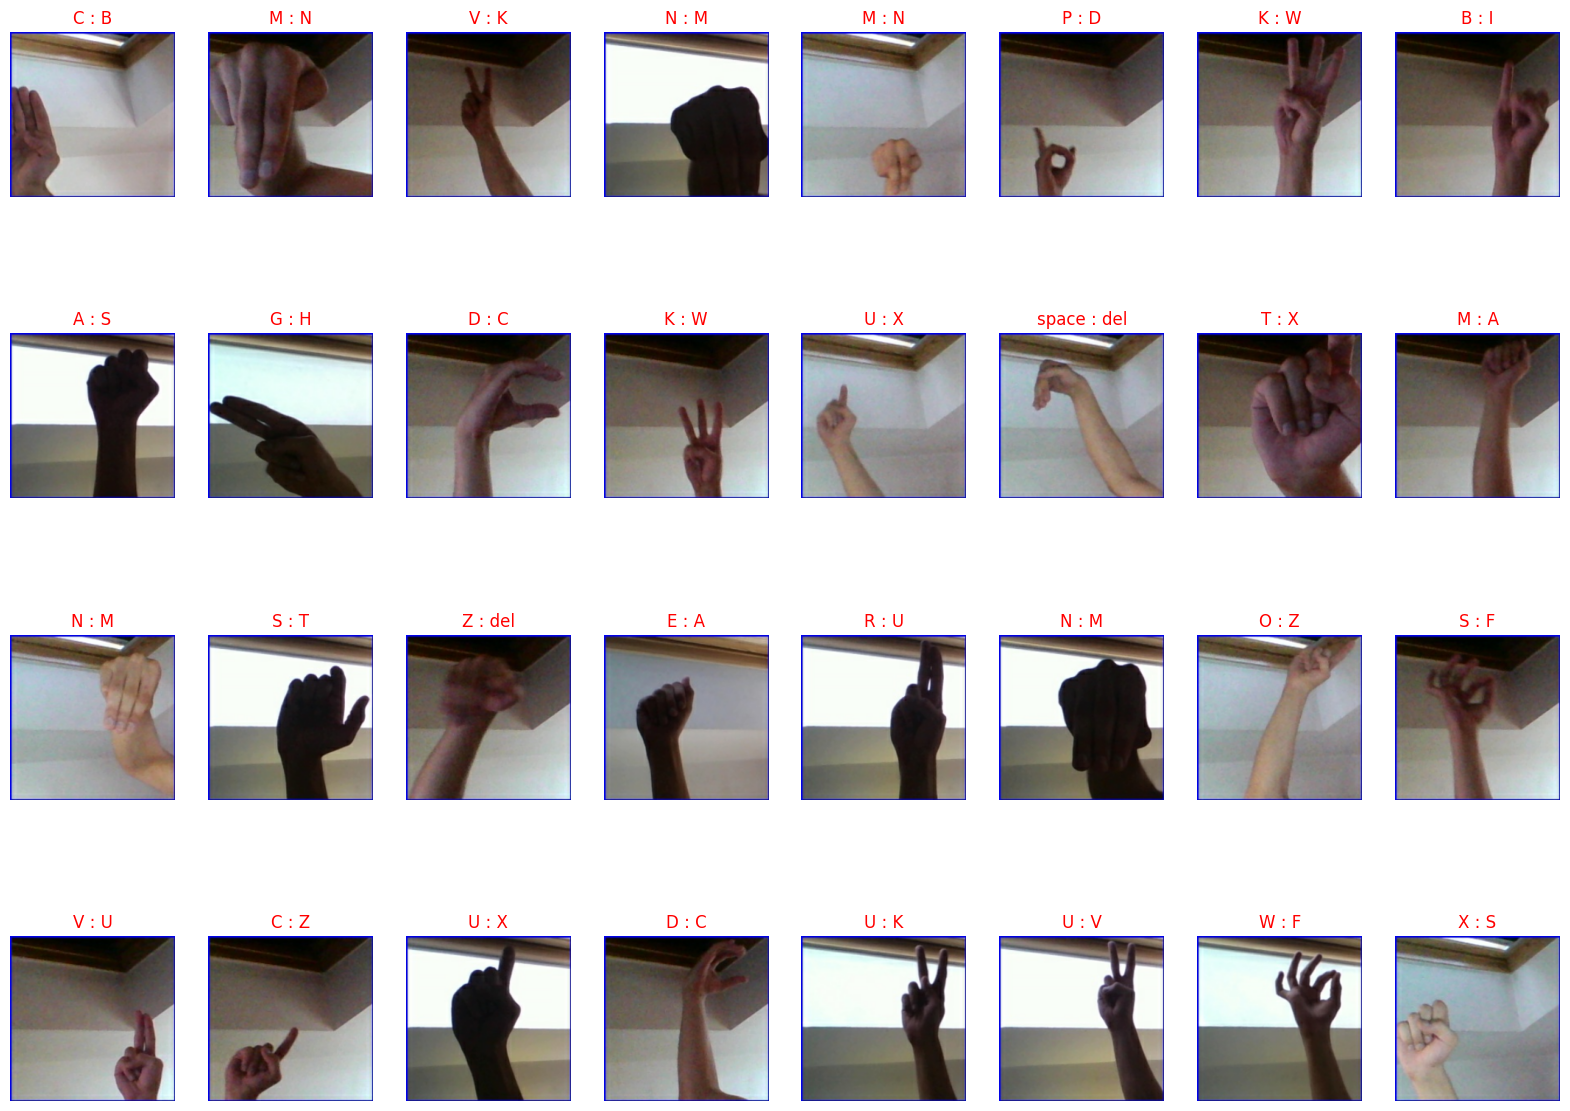

In [17]:
displayWrongPredictions(savedModel, validDataset)